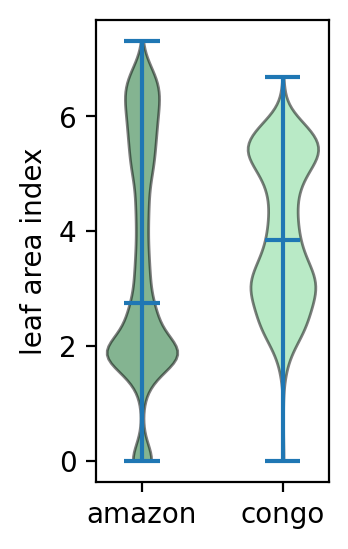

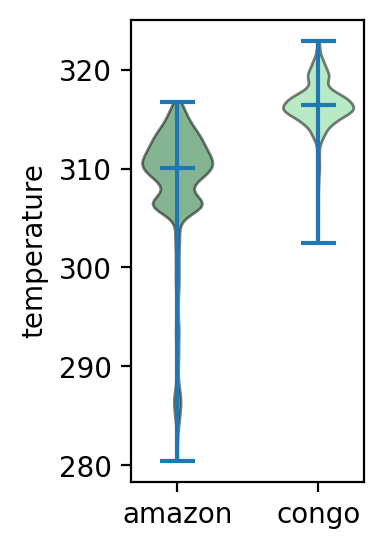

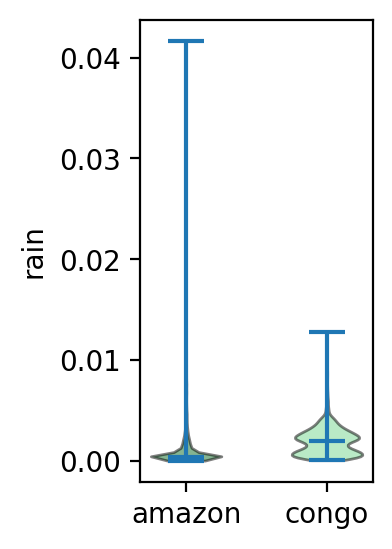

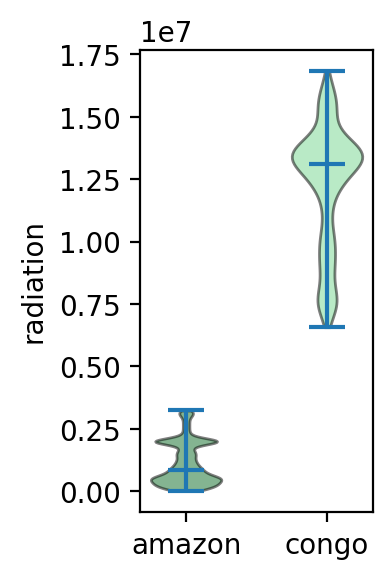

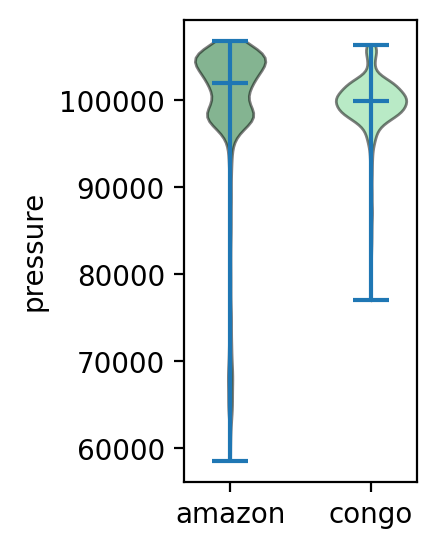

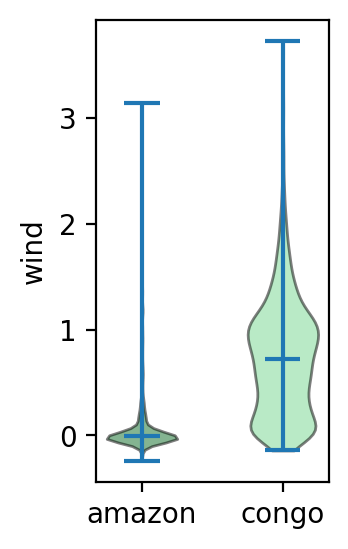

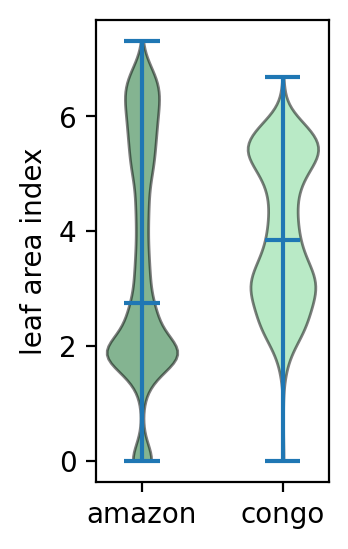

In [6]:
# -*- coding: utf-8 -*-
"""
Created on Sun May  5 15:05:31 2024

@author: haofg
"""
import numpy as np
import numpy.ma as ma
import h5py
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
inputs = ['lai_hv_interp',
          'temperature_interp','rain_interp','radiation_interp',
          'pressure_interp','wind_interp','lai_hv_interp']
col_names = ['leaf area index',
          'temperature','rain','radiation',
          'pressure','wind','leaf area index']
i=1
congodir='../congoCodes/good_data/'
for var, name in zip(inputs, col_names):
    amazon = np.load(var+'_025.npy')
    amazon = amazon[~np.isnan(amazon)]
    congo = np.load(congodir+var+'_congo_025.npy')
    congo = congo[~np.isnan(congo)]
    #plt.subplot(6,1,i)
    i+=1
    figure(figsize=(1.5,3), dpi=200)
    violin_plot = plt.violinplot(
        [amazon,congo], 
        showmeans=False, showmedians=True)
    for i, pc in enumerate(violin_plot["bodies"], 1):
        if i%2 != 0:
            pc.set_facecolor('#0a6b24')
            pc.set_edgecolor('black')
            pc.set_alpha(0.5)
        else:
            pc.set_facecolor('#74d68e')
            pc.set_edgecolor('black')
            pc.set_alpha(0.5)
    plt.ylabel(name)
    plt.xticks([1,2], labels=['amazon', 'congo'])
    
    mydir = '../../../ICDS_paper/Graphs/'
    plt.savefig(mydir + 'violin'+name+'.png', bbox_inches="tight")
    plt.show()